# Movie Dataset Analysis - Level 2

Analysis of the 1980-2001 movie dataset across three exercises:
1. Budget vs. financial and critical success
2. Reliability of directors and production companies
3. Genre, country, and audience trends over time

## Setup: Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Consistent plot styling for the whole notebook, set once instead of repeating it in every cell
plt.rcParams['figure.figsize'] = (12, 7)
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['figure.dpi'] = 100
sns.set_style('whitegrid')

## Load and Clean the Data

In [2]:
# Load the dataset
movies = pd.read_excel('movies_updated.xlsx')

# The runtime column name came in with extra commas, fix the name and convert it to a number
movies.rename(columns={'runtime,,': 'runtime'}, inplace=True)
movies['runtime'] = movies['runtime'].astype(str).str.replace(',', '').str.strip()
movies['runtime'] = pd.to_numeric(movies['runtime'], errors='coerce')

print(f'{len(movies):,} movies, {movies["year"].min()}-{movies["year"].max()}')
movies.head()

4,000 movies, 1980-2001


,name,rating,genre,year,released,score,votes,director,writer,star,country,budget,gross,company,runtime
0,The Shining,R,Drama,1980,"June 13, 1980 (United States)",8.4,927000,Stanley Kubrick,Stephen King,Jack Nicholson,United Kingdom,19000000,46998772.0,Warner Bros.,146.0
1,The Blue Lagoon,R,Adventure,1980,"July 2, 1980 (United States)",5.8,65000,Randal Kleiser,Henry De Vere Stacpoole,Brooke Shields,United States,4500000,58853106.0,Columbia Pictures,104.0
2,Star Wars: Episode V - The Empire Strikes Back,PG,Action,1980,"June 20, 1980 (United States)",8.7,1200000,Irvin Kershner,Leigh Brackett,Mark Hamill,United States,18000000,538375067.0,Lucasfilm,124.0
3,Airplane!,PG,Comedy,1980,"July 2, 1980 (United States)",7.7,221000,Jim Abrahams,Jim Abrahams,Robert Hays,United States,3500000,83453539.0,Paramount Pictures,88.0
4,Caddyshack,R,Comedy,1980,"July 25, 1980 (United States)",7.3,108000,Harold Ramis,Brian Doyle-Murray,Chevy Chase,United States,6000000,39846344.0,Orion Pictures,98.0


# Exercise 1: Does a Bigger Budget Mean Bigger Success?

### Assumptions
ROI is undefined when budget = 0, and 1,392 movies (35%) have budget = 0. That looks like missing data rather than an actual free movie, so those rows are dropped for any ROI-based analysis, along with rows missing budget, gross, or score.

## Task 1-2: Create ROI and Clean the Data

In [3]:
# Drop rows missing the values ROI depends on
movies_clean = movies.dropna(subset=['budget', 'gross', 'score']).copy()

# budget = 0 makes ROI undefined (division by zero) and almost certainly means missing data, not a free movie
movies_clean = movies_clean[movies_clean['budget'] > 0]

# ROI: how much a movie made back relative to what it cost
movies_clean['ROI'] = (movies_clean['gross'] - movies_clean['budget']) / movies_clean['budget']

print(f'Rows before cleaning: {len(movies):,}')
print(f'Rows after cleaning:  {len(movies_clean):,}')
movies_clean['ROI'].describe()

Rows before cleaning: 4,000
Rows after cleaning:  2,559


count    2559.000000
mean        3.736646
std        82.297774
min        -0.999979
25%        -0.520625
50%         0.367533
75%         2.085190
max      4142.984983
Name: ROI, dtype: float64

## Task 3-5: Budget vs Gross vs Score vs Votes, with Top 10 ROI Annotated

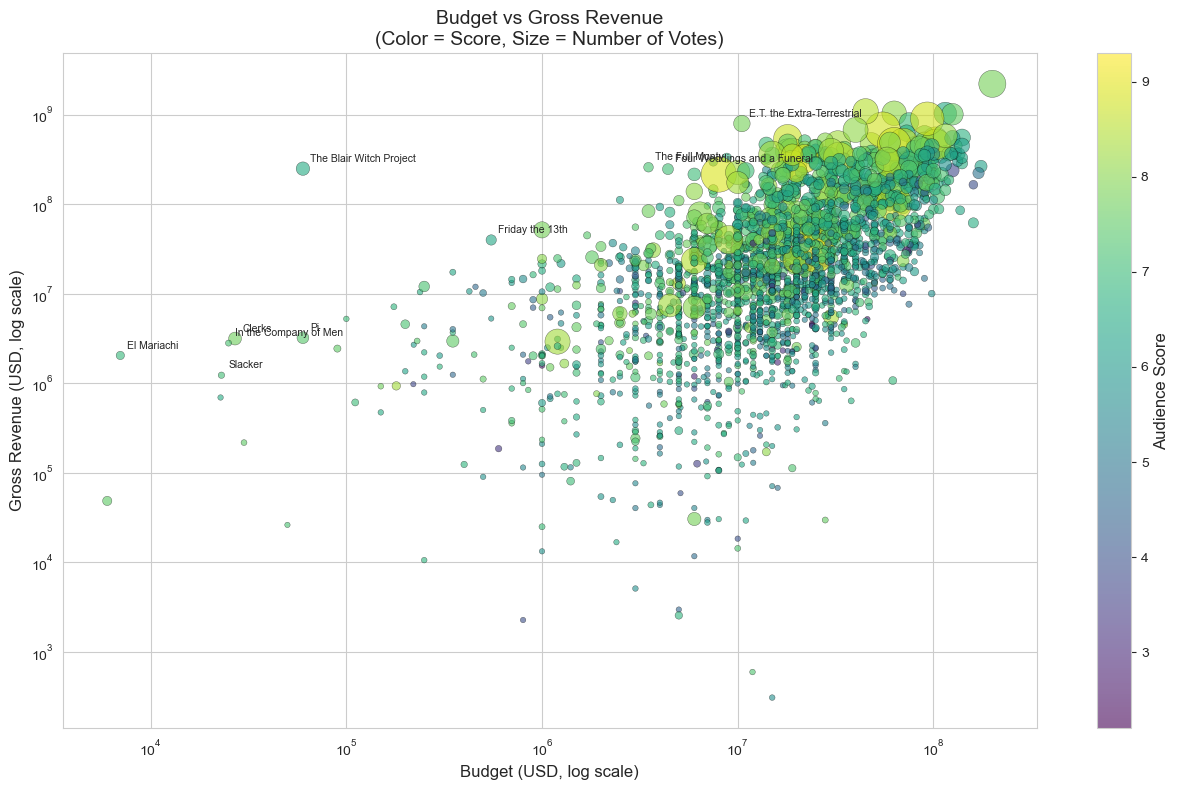

,name,budget,gross,score,ROI
3459,The Blair Witch Project,60000,248639099.0,6.5,4142.984983
2093,El Mariachi,7000,2040920.0,6.9,290.560000
2467,Clerks,27000,3151130.0,7.7,115.708519
3233,In the Company of Men,25000,2804473.0,7.2,111.178920
209,E.T. the Extra-Terrestrial,10500000,792910554.0,7.8,74.515291
3089,The Full Monty,3500000,257938649.0,7.2,72.696757
5,Friday the 13th,550000,39754601.0,6.4,71.281093
2458,Four Weddings and a Funeral,4400000,245700832.0,7.1,54.841098
3291,Pi,60000,3221152.0,7.4,52.685867
1684,Slacker,23000,1228108.0,7.1,52.396000


In [4]:
# Highest-ROI movies, used later to label the scatter plot
top_roi_movies = movies_clean.sort_values('ROI', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(13, 8))

# Bubble size encodes vote count, scaled so even the smallest bubble stays visible
marker_sizes = (movies_clean['votes'] / movies_clean['votes'].max()) * 800 + 15

scatter_plot = ax.scatter(
    movies_clean['budget'],
    movies_clean['gross'],
    c=movies_clean['score'],      # color encodes score
    s=marker_sizes,                # size encodes votes
    cmap='viridis',
    alpha=0.6,
    edgecolor='black',
    linewidth=0.3
)

# Budget and gross both span several orders of magnitude, a log scale keeps cheap and
# expensive movies from being squashed into the same corner of the plot
ax.set_xscale('log')
ax.set_yscale('log')

ax.set_xlabel('Budget (USD, log scale)')
ax.set_ylabel('Gross Revenue (USD, log scale)')
ax.set_title('Budget vs Gross Revenue\n(Color = Score, Size = Number of Votes)')

colorbar = plt.colorbar(scatter_plot, ax=ax)
colorbar.set_label('Audience Score')

# Label the 10 highest-ROI movies directly on the plot
for _, movie in top_roi_movies.iterrows():
    ax.annotate(
        movie['name'],
        (movie['budget'], movie['gross']),
        fontsize=7.5,
        xytext=(5, 5),
        textcoords='offset points'
    )

plt.tight_layout()
plt.savefig('budget_vs_gross_scatter.png', bbox_inches='tight')
plt.show()

top_roi_movies[['name', 'budget', 'gross', 'score', 'ROI']]

## Task 6: ROI Distribution Across the Top 10 Genres

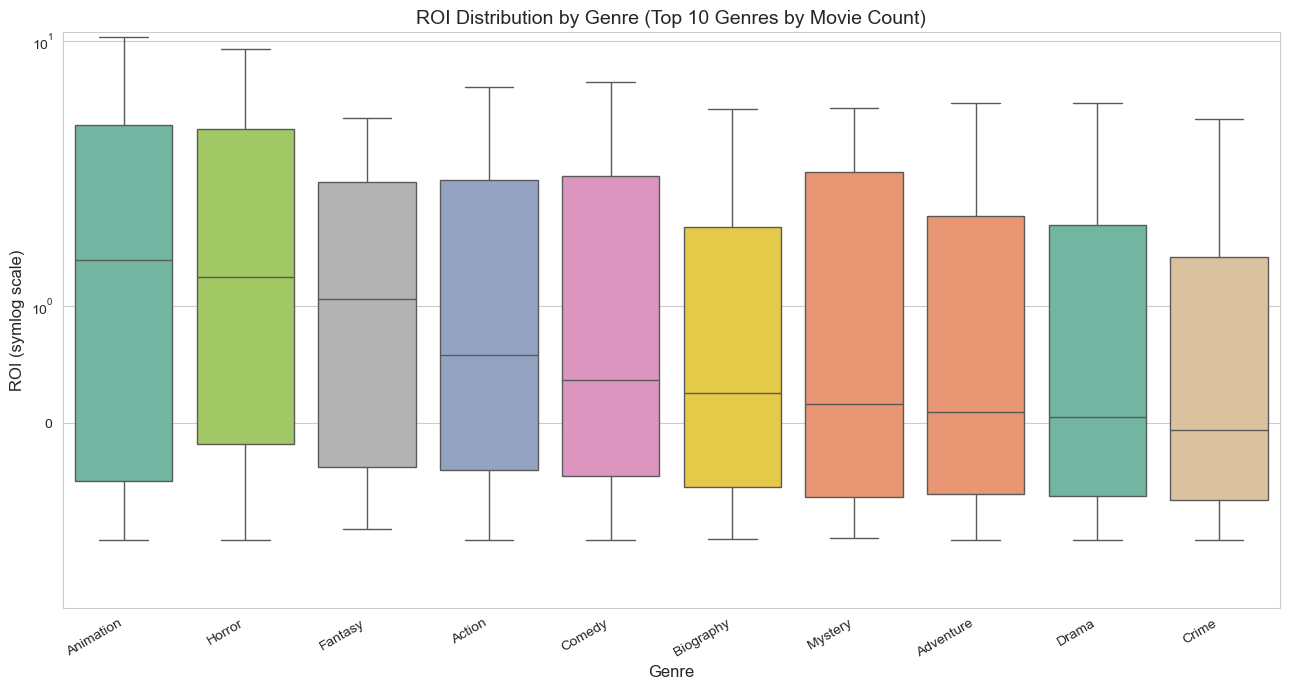

genre
Animation    1.391979
Horror       1.245093
Fantasy      1.060715
Action       0.578256
Comedy       0.367100
Biography    0.261958
Mystery      0.160255
Adventure    0.096643
Drama        0.052628
Crime       -0.055319
Name: ROI, dtype: float64

In [5]:
# Restrict to the 10 most common genres, so the boxplot isn't diluted by genres with too few movies
top_10_genres = movies['genre'].value_counts().head(10).index
genre_roi = movies_clean[movies_clean['genre'].isin(top_10_genres)].copy()

# Order genres by median ROI so the chart reads highest to lowest, left to right
genre_order = genre_roi.groupby('genre')['ROI'].median().sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(13, 7))
sns.boxplot(data=genre_roi, x='genre', y='ROI', order=genre_order, hue='genre',
            legend=False, ax=ax, showfliers=False, palette='Set2')

# ROI has extreme outliers in both directions, symlog keeps the boxes readable without
# distorting the values that sit close to zero
ax.set_yscale('symlog')
ax.set_title('ROI Distribution by Genre (Top 10 Genres by Movie Count)')
ax.set_xlabel('Genre')
ax.set_ylabel('ROI (symlog scale)')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('ex1_genre_roi_boxplot.png', bbox_inches='tight')
plt.show()

genre_roi.groupby('genre')['ROI'].median().sort_values(ascending=False)

## Task 7: Answers

In [6]:
# Numbers referenced in the written answers below
print('Correlation budget vs gross:', round(movies_clean['budget'].corr(movies_clean['gross']), 3))
print('Correlation score vs ROI:   ', round(movies_clean['score'].corr(movies_clean['ROI']), 3))
print()
print('High score, terrible ROI example:')
print(movies_clean[movies_clean['score'] >= 7.5].sort_values('ROI').head(3)[['name', 'score', 'ROI']].to_string(index=False))
print()
print('Low score, huge ROI example:')
print(movies_clean[movies_clean['score'] < 6].sort_values('ROI', ascending=False).head(3)[['name', 'score', 'ROI']].to_string(index=False))

Correlation budget vs gross: 0.548
Correlation score vs ROI:    0.02

High score, terrible ROI example:
                    name  score       ROI
The Lovers on the Bridge    7.6 -0.998940
     The Boondock Saints    7.8 -0.994922
             Underground    8.1 -0.987780

Low score, huge ROI example:
              name  score       ROI
Look Who's Talking    5.9 38.599975
      Deathstalker    4.6 25.081510
            Cyborg    5.1 19.332918


### Task 7 Answers
1. **Do larger budgets generally result in higher revenue?** Yes, moderately. Budget and gross have a positive correlation of about 0.55, so bigger budgets tend to buy bigger box office, but the relationship isn't tight - plenty of high-budget films underperform and a few micro-budget films (The Blair Witch Project, El Mariachi) massively outperform.
2. **Which genre generates the highest returns relative to investment?** Animation, followed by Horror, have the highest median ROI among the top 10 genres. Both are historically cheap to produce relative to the audience they reach.
3. **Are highly rated movies always financially successful?** No. The correlation between score and ROI is close to zero (about 0.02). Some critically liked films (score >= 7.5) posted near total losses, while some poorly rated films (score < 6) returned 15-38x their budget. Critical reception and financial return are largely independent here.

# Exercise 2: Reliable Directors and Production Companies

### Assumptions
- 16 movies list director as "Directors", a placeholder for multi-director or anthology films like Twilight Zone: The Movie. These are excluded from the director analysis only.
- Company ROI reuses the cleaned data from Exercise 1 (movies_clean), since ROI is undefined when budget = 0.

## Task 1-2: Director Statistics (at least 5 movies)

In [7]:
# "Directors" is a placeholder for multi-director/anthology films, not a real director, exclude it
movies_with_director = movies[movies['director'] != 'Directors']

director_stats = movies_with_director.groupby('director').agg(
    n_movies=('name', 'count'),
    avg_score=('score', 'mean'),
    median_score=('score', 'median'),
    std_score=('score', 'std')
).reset_index()

# Need at least 5 movies for average/std to mean anything.
# std comes back NaN for directors with only one qualifying score, treat that as zero variance
director_stats = director_stats[director_stats['n_movies'] >= 5].fillna({'std_score': 0})

print(f'{len(director_stats)} directors qualify with at least 5 movies')
director_stats.sort_values('avg_score', ascending=False).head(10)

215 directors qualify with at least 5 movies


,director,n_movies,avg_score,median_score,std_score
428,Emir Kusturica,5,7.900000,8.10,0.367423
656,James Cameron,6,7.883333,7.90,0.487511
545,Giuseppe Tornatore,6,7.816667,7.70,0.411906
1506,Steven Spielberg,14,7.664286,7.75,0.749982
767,Joel Coen,9,7.655556,7.70,0.308671
1124,Mike Leigh,5,7.620000,7.50,0.268328
741,Jim Jarmusch,6,7.600000,7.60,0.089443
875,Kar-Wai Wong,6,7.583333,7.60,0.475044
1031,Martin Scorsese,11,7.581818,7.50,0.599697
1369,Robert Zemeckis,10,7.560000,7.60,0.735149


## Task 3: Visualizing Director Reliability

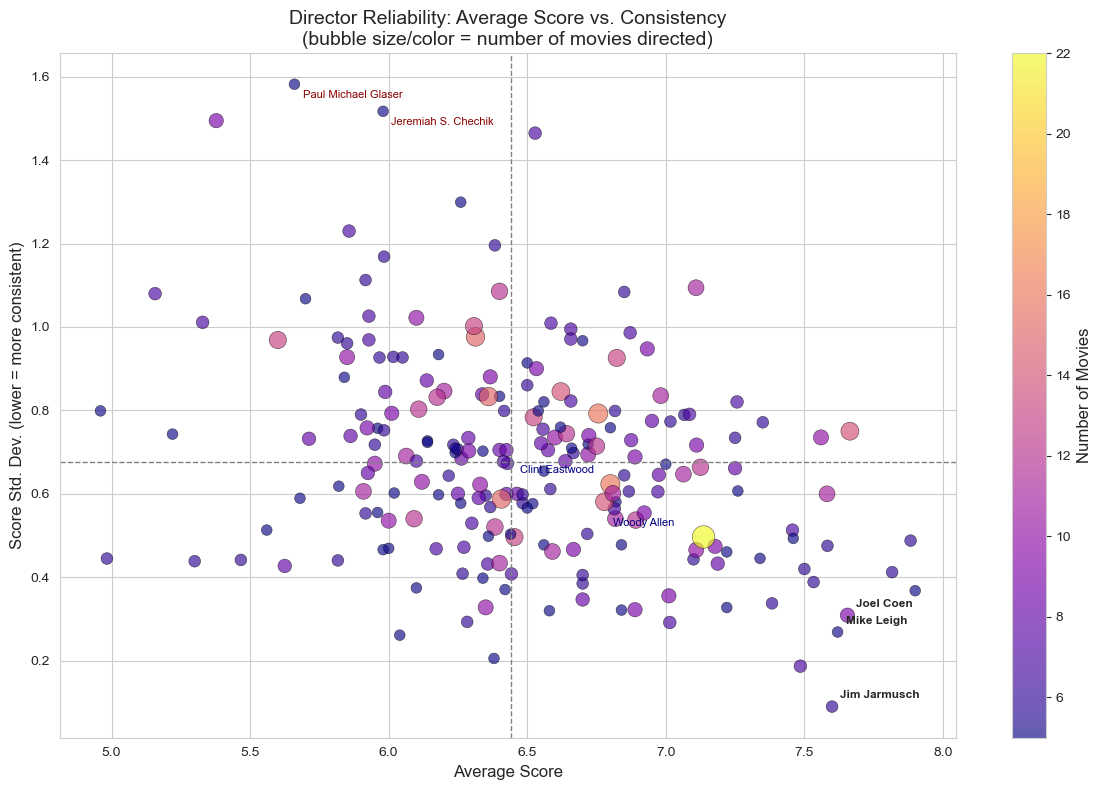

,director,n_movies,avg_score,std_score
741,Jim Jarmusch,6,7.600000,0.089443
1124,Mike Leigh,5,7.620000,0.268328
767,Joel Coen,9,7.655556,0.308671


In [8]:
fig, ax = plt.subplots(figsize=(12, 8))

# Bubble size and color both reflect how many movies the director made
sizes = director_stats['n_movies'] * 12
sc = ax.scatter(director_stats['avg_score'], director_stats['std_score'], s=sizes,
                 c=director_stats['n_movies'], cmap='plasma', alpha=0.65, edgecolor='k', linewidth=0.4)

# Median lines split the chart into four quadrants: high/low score x high/low consistency
ax.axvline(director_stats['avg_score'].median(), color='gray', linestyle='--', linewidth=1)
ax.axhline(director_stats['std_score'].median(), color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Average Score')
ax.set_ylabel('Score Std. Dev. (lower = more consistent)')
ax.set_title('Director Reliability: Average Score vs. Consistency\n(bubble size/color = number of movies directed)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Number of Movies')

# Combine score rank and consistency rank to find directors who are both good and reliable
director_stats['rank_score'] = director_stats['avg_score'].rank(ascending=False)
director_stats['rank_consistency'] = director_stats['std_score'].rank(ascending=True)
director_stats['combined_rank'] = director_stats['rank_score'] + director_stats['rank_consistency']
most_reliable = director_stats.sort_values('combined_rank').head(3)
for _, r in most_reliable.iterrows():
    ax.annotate(r['director'], (r['avg_score'], r['std_score']), fontsize=8.5, fontweight='bold',
                xytext=(6, 6), textcoords='offset points')

most_inconsistent = director_stats.sort_values('std_score', ascending=False).head(2)
for _, r in most_inconsistent.iterrows():
    ax.annotate(r['director'], (r['avg_score'], r['std_score']), fontsize=8, color='darkred',
                xytext=(6, -10), textcoords='offset points')

most_productive = director_stats.sort_values('n_movies', ascending=False).head(2)
for _, r in most_productive.iterrows():
    ax.annotate(r['director'], (r['avg_score'], r['std_score']), fontsize=8, color='navy',
                xytext=(-65, 8), textcoords='offset points')

plt.tight_layout()
plt.savefig('ex2_director_reliability.png', bbox_inches='tight')
plt.show()

most_reliable[['director', 'n_movies', 'avg_score', 'std_score']]

## Task 4-5: Production Company Statistics (at least 20 movies), All 4 Metrics at Once

18 companies qualify with at least 20 movies


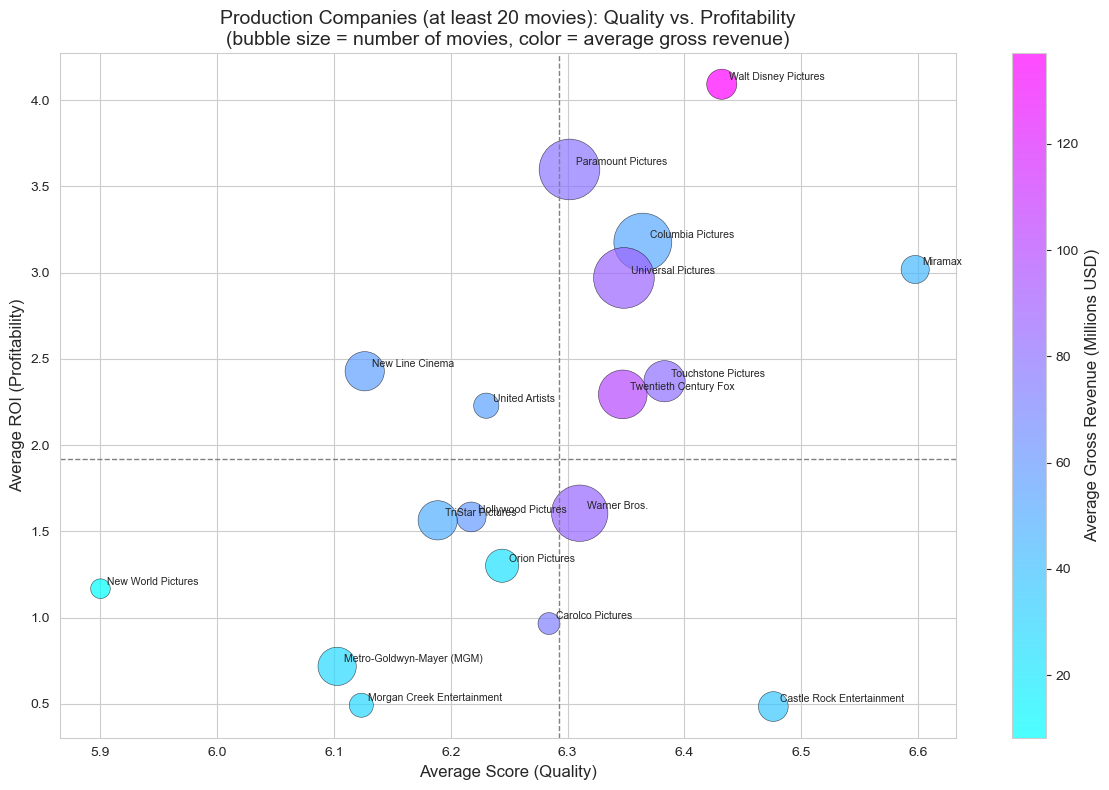

In [9]:
company_stats = movies.groupby('company').agg(
    n_movies=('name', 'count'),
    avg_gross=('gross', 'mean'),
    avg_score=('score', 'mean')
).reset_index()

# ROI needs the cleaned data from Exercise 1, since it's undefined for budget = 0
company_roi = movies_clean.groupby('company')['ROI'].mean().reset_index().rename(columns={'ROI': 'avg_roi'})
company_stats = company_stats.merge(company_roi, on='company', how='left')

# Need at least 20 movies, and a usable ROI value, to qualify
company_stats = company_stats[company_stats['n_movies'] >= 20].dropna(subset=['avg_roi'])

print(f'{len(company_stats)} companies qualify with at least 20 movies')

fig, ax = plt.subplots(figsize=(12, 8))
sizes = company_stats['n_movies'] * 10
sc = ax.scatter(company_stats['avg_score'], company_stats['avg_roi'], s=sizes,
                 c=company_stats['avg_gross'] / 1e6, cmap='cool', alpha=0.7, edgecolor='k', linewidth=0.4)
for _, r in company_stats.iterrows():
    ax.annotate(r['company'], (r['avg_score'], r['avg_roi']), fontsize=7.5, xytext=(5, 3), textcoords='offset points')

# Median lines split companies into quality vs profitability quadrants
med_score, med_roi = company_stats['avg_score'].median(), company_stats['avg_roi'].median()
ax.axhline(med_roi, color='gray', linestyle='--', linewidth=1)
ax.axvline(med_score, color='gray', linestyle='--', linewidth=1)
ax.set_xlabel('Average Score (Quality)')
ax.set_ylabel('Average ROI (Profitability)')
ax.set_title('Production Companies (at least 20 movies): Quality vs. Profitability\n'
             '(bubble size = number of movies, color = average gross revenue)')
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label('Average Gross Revenue (Millions USD)')
plt.tight_layout()
plt.savefig('ex2_company_quality_vs_profit.png', bbox_inches='tight')
plt.show()

## Task 6: Answers

In [10]:
quality_over_profit = company_stats[(company_stats['avg_score'] >= med_score) & (company_stats['avg_roi'] < med_roi)]\
    .sort_values('avg_score', ascending=False)
profit_over_quality = company_stats[(company_stats['avg_score'] < med_score) & (company_stats['avg_roi'] >= med_roi)]\
    .sort_values('avg_roi', ascending=False)

print('Quality-over-profitability companies (above-median score, below-median ROI):')
print(quality_over_profit[['company', 'avg_score', 'avg_roi', 'n_movies']].to_string(index=False))
print()
print('Profitability-over-quality companies (below-median score, above-median ROI):')
print(profit_over_quality[['company', 'avg_score', 'avg_roi', 'n_movies']].to_string(index=False))

Quality-over-profitability companies (above-median score, below-median ROI):
                  company  avg_score  avg_roi  n_movies
Castle Rock Entertainment   6.476087 0.484668        46
             Warner Bros.   6.310303 1.605360       165

Profitability-over-quality companies (below-median score, above-median ROI):
        company  avg_score  avg_roi  n_movies
New Line Cinema   6.126250 2.428622        80
 United Artists   6.230303 2.228752        33


### Task 6 Answers
1. **Three consistently successful directors:** Jim Jarmusch, Mike Leigh, and Joel Coen rank best on a combined score-and-consistency measure - high average scores (7.6+) with very low variance, meaning their quality rarely dips. Honorable mention: Woody Allen, who pairs a strong average score with the highest output of any director with at least 5 movies (22 films).
2. **Companies that prioritize quality over profitability:** Castle Rock Entertainment and Warner Bros. sit above the median score but below the median ROI - solid critical output that doesn't translate into top-tier returns.
3. **Companies that prioritize profitability over quality:** New Line Cinema and United Artists sit below the median score but above the median ROI - strong financial returns despite more middling reception.

# Exercise 3: Trends Across Time, Genre, and Country

### Assumptions
- The dataset spans 1980-2001, so the 2000s bucket only has 2 years (2000-2001) of data, not a full decade. Raw counts for the 2000s would look artificially low just from the shorter window, so genre trends are shown as a percent share within each decade instead.
- The median vote count used in the Hidden Gem definition is computed once, globally, across all 4,000 movies.

## Task 1-2: Decade and Genre Statistics

In [11]:
# Group years into decades
movies['decade'] = (movies['year'] // 10) * 10

decade_genre_stats = movies.groupby(['decade', 'genre']).agg(
    n_movies=('name', 'count'),
    avg_score=('score', 'mean'),
    total_gross=('gross', 'sum')
).reset_index()

print(movies['decade'].value_counts().sort_index().rename('movies per decade'))
decade_genre_stats.sort_values(['decade', 'n_movies'], ascending=[True, False]).head(10)

decade
1980    1643
1990    2000
2000     357
Name: movies per decade, dtype: int64


,decade,genre,n_movies,avg_score,total_gross
4,1980,Comedy,565,6.090619,1.155346e+10
0,1980,Action,320,5.969688,1.164296e+10
6,1980,Drama,312,6.510256,4.743267e+09
1,1980,Adventure,105,6.194286,2.819619e+09
5,1980,Crime,99,6.497980,1.301625e+09
10,1980,Horror,95,5.808421,1.020685e+09
3,1980,Biography,66,6.934848,1.360413e+09
2,1980,Animation,37,6.981081,1.084387e+09
8,1980,Fantasy,16,6.168750,2.983655e+08
15,1980,Thriller,10,5.840000,3.868978e+07


## Task 3: Genre Popularity Across Decades

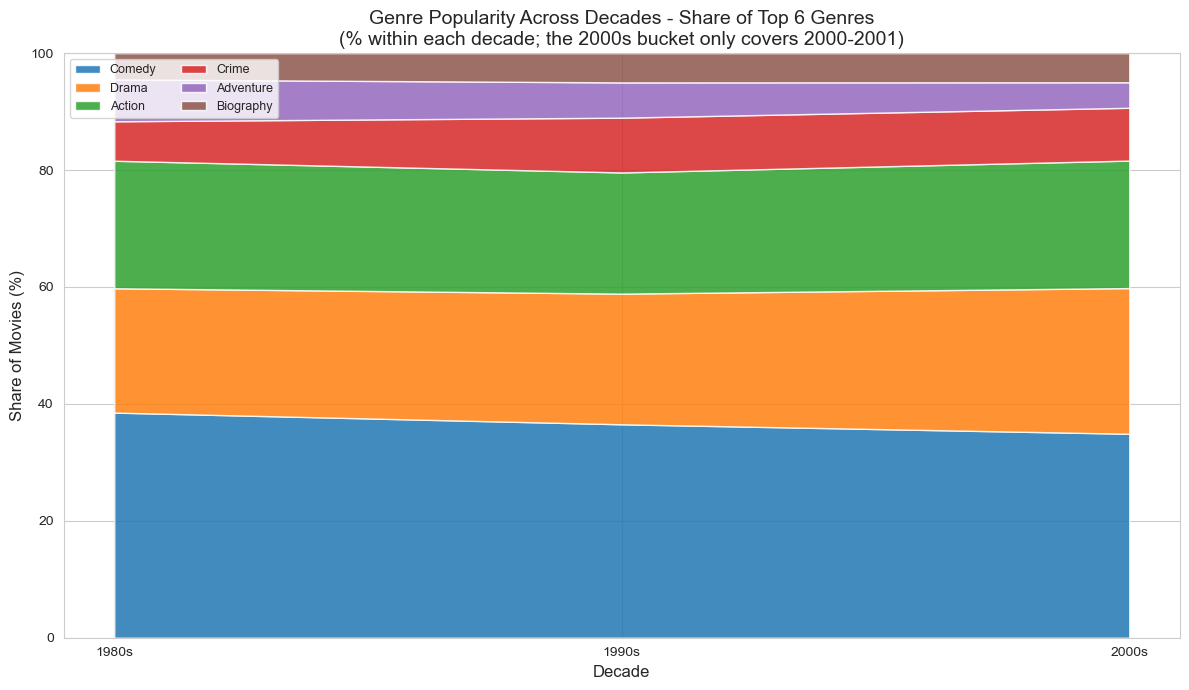

genre
Drama        3.654225
Crime        2.285802
Biography    0.485446
Action      -0.006371
Adventure   -2.796093
Comedy      -3.623008
Name: share change, 1980s to 2000s (pp), dtype: float64

In [12]:
top_6_genres = movies['genre'].value_counts().head(6).index.tolist()
genre_decade_pivot = decade_genre_stats[decade_genre_stats['genre'].isin(top_6_genres)]\
    .pivot(index='decade', columns='genre', values='n_movies').fillna(0)
genre_decade_pivot = genre_decade_pivot[top_6_genres]

# Share of movies per decade rather than raw counts, since the 2000s bucket only has 2 years of data
genre_decade_share = genre_decade_pivot.div(genre_decade_pivot.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 7))
ax.stackplot(genre_decade_share.index, [genre_decade_share[g] for g in top_6_genres], labels=top_6_genres, alpha=0.85)
ax.set_xlabel('Decade')
ax.set_ylabel('Share of Movies (%)')
ax.set_title('Genre Popularity Across Decades - Share of Top 6 Genres\n'
             '(% within each decade; the 2000s bucket only covers 2000-2001)')
ax.set_xticks(genre_decade_share.index)
ax.set_xticklabels([f'{d}s' for d in genre_decade_share.index])
ax.set_ylim(0, 100)
ax.legend(loc='upper left', fontsize=9, ncol=2)
plt.tight_layout()
plt.savefig('ex3_genre_decade_share.png', bbox_inches='tight')
plt.show()

# How much each genre's share changed from the 1980s to the 2000s
(genre_decade_share.loc[2000] - genre_decade_share.loc[1980]).sort_values(ascending=False)\
    .rename('share change, 1980s to 2000s (pp)')

## Task 4-6: Country Comparison (at least 30 movies)

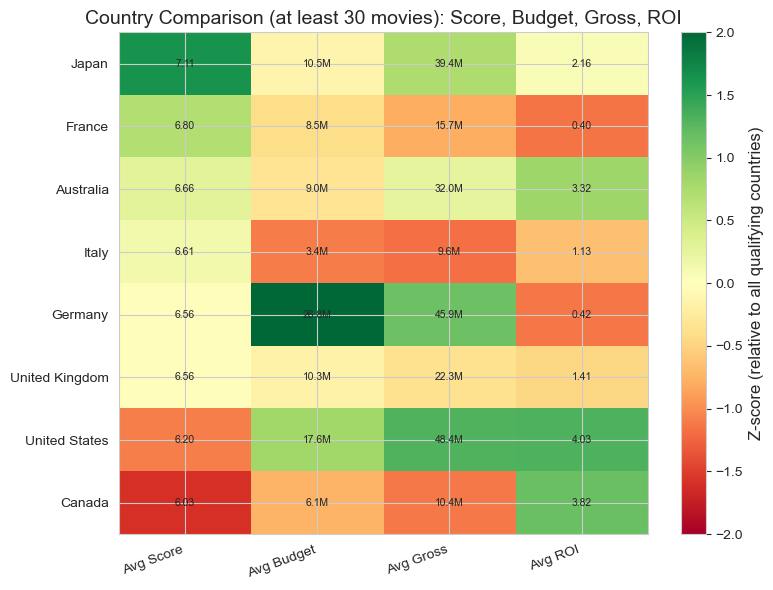

,avg_score,avg_budget,score_per_million_budget
country,,,
Italy,6.611111,3.406667e+06,1.940639
Canada,6.030000,6.092006e+06,0.989822
France,6.798000,8.513333e+06,0.798512
Australia,6.660377,9.016038e+06,0.738726
Japan,7.108889,1.051778e+07,0.675893
United Kingdom,6.555808,1.033168e+07,0.634535
United States,6.200942,1.764754e+07,0.351377
Germany,6.560465,2.675581e+07,0.245198


In [13]:
# Only keep countries with at least 30 movies, otherwise the averages are too noisy to compare
country_counts = movies['country'].value_counts()
valid_countries = country_counts[country_counts >= 30].index

country_stats = movies[movies['country'].isin(valid_countries)].groupby('country').agg(
    avg_score=('score', 'mean'),
    avg_budget=('budget', 'mean'),
    avg_gross=('gross', 'mean')
).reset_index()

# ROI needs the cleaned data from Exercise 1
country_roi = movies_clean[movies_clean['country'].isin(valid_countries)].groupby('country')['ROI'].mean()\
    .reset_index().rename(columns={'ROI': 'avg_roi'})
country_stats = country_stats.merge(country_roi, on='country', how='left').set_index('country')

# Z-score each metric so score, budget, gross, and ROI can sit on the same color scale
country_zscores = (country_stats - country_stats.mean()) / country_stats.std()
country_zscores = country_zscores.sort_values('avg_score', ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(country_zscores.values, cmap='RdYlGn', aspect='auto', vmin=-2, vmax=2)
ax.set_xticks(range(len(country_zscores.columns)))
ax.set_xticklabels(['Avg Score', 'Avg Budget', 'Avg Gross', 'Avg ROI'], rotation=20, ha='right')
ax.set_yticks(range(len(country_zscores.index)))
ax.set_yticklabels(country_zscores.index)

# Show the real value in each cell, the color still represents the z-score
for i in range(len(country_zscores.index)):
    for j, col in enumerate(country_stats.columns):
        val = country_stats.loc[country_zscores.index[i], col]
        label = f'{val:,.2f}' if col in ('avg_score', 'avg_roi') else f'{val/1e6:,.1f}M'
        ax.text(j, i, label, ha='center', va='center', fontsize=7.5)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Z-score (relative to all qualifying countries)')
ax.set_title('Country Comparison (at least 30 movies): Score, Budget, Gross, ROI')
plt.tight_layout()
plt.savefig('ex3_country_heatmap.png', bbox_inches='tight')
plt.show()

# Score per million dollars of budget, a simple way to see which countries get the most quality per dollar
country_stats['score_per_million_budget'] = country_stats['avg_score'] / (country_stats['avg_budget'] / 1e6)
country_stats.sort_values('score_per_million_budget', ascending=False)[['avg_score', 'avg_budget', 'score_per_million_budget']]

## Task 7-9: Hidden Gems

Global median votes: 13,000
Total hidden gems found: 5 out of 4,000 movies


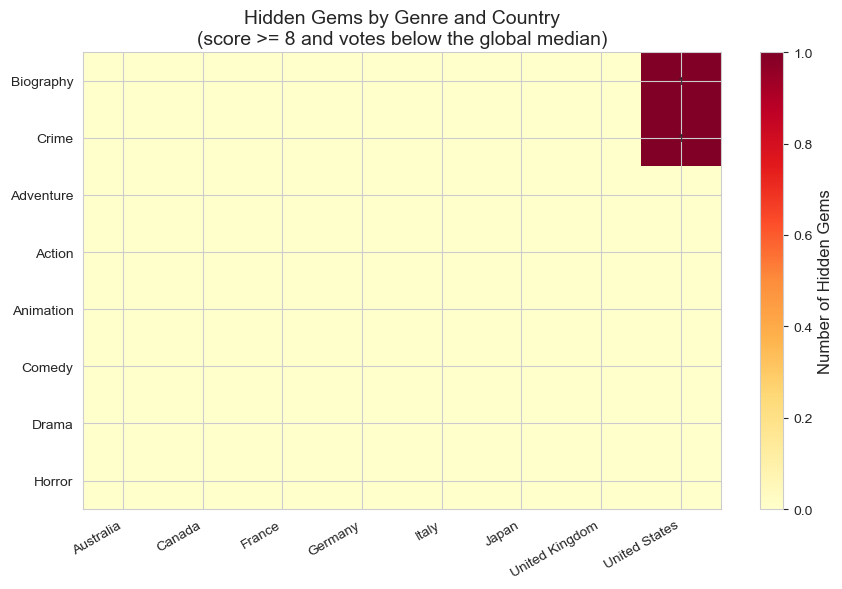

,name,year,genre,country,score,votes
474,The Business of Show Business,1983,History,Canada,8.3,79
573,Repentance,1984,Drama,Soviet Union,8.3,4100
66,Moscow Does Not Believe in Tears,1980,Comedy,Soviet Union,8.1,12000
724,Mishima: A Life in Four Chapters,1985,Biography,United States,8.0,10000
1370,Salaam Bombay!,1988,Crime,United States,8.0,8800


In [14]:
# A hidden gem: well reviewed but not widely seen
median_votes = movies['votes'].median()
movies['hidden_gem'] = (movies['score'] >= 8) & (movies['votes'] < median_votes)
print(f'Global median votes: {median_votes:,.0f}')
print(f'Total hidden gems found: {movies["hidden_gem"].sum()} out of {len(movies):,} movies')

# Restrict to genres/countries with enough movies that the counts are meaningful
top_8_genres = movies['genre'].value_counts().head(8).index
gem_counts = movies[movies['genre'].isin(top_8_genres) & movies['country'].isin(valid_countries)]\
    .groupby(['genre', 'country'])['hidden_gem'].sum().reset_index()
gem_pivot = gem_counts.pivot(index='genre', columns='country', values='hidden_gem').fillna(0)
gem_pivot = gem_pivot.loc[gem_pivot.sum(axis=1).sort_values(ascending=False).index]

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(gem_pivot.values, cmap='YlOrRd', aspect='auto')
ax.set_xticks(range(len(gem_pivot.columns)))
ax.set_xticklabels(gem_pivot.columns, rotation=30, ha='right')
ax.set_yticks(range(len(gem_pivot.index)))
ax.set_yticklabels(gem_pivot.index)

# Only label cells with at least one hidden gem, zeros would just clutter the chart
for i in range(len(gem_pivot.index)):
    for j in range(len(gem_pivot.columns)):
        v = int(gem_pivot.values[i, j])
        if v > 0:
            ax.text(j, i, str(v), ha='center', va='center', fontsize=8)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Number of Hidden Gems')
ax.set_title('Hidden Gems by Genre and Country\n(score >= 8 and votes below the global median)')
plt.tight_layout()
plt.savefig('ex3_hidden_gems.png', bbox_inches='tight')
plt.show()

movies[movies['hidden_gem']][['name', 'year', 'genre', 'country', 'score', 'votes']].sort_values('score', ascending=False)

## Task 10: Answers

### Task 10 Answers
1. **Which genres gained popularity over time?** Looking at share of movies per decade rather than raw counts (since the 2000s bucket is only 2 years): Drama (+3.7 percentage points from the 1980s to the 2000s) and Crime (+2.3pp) grew the most, while Comedy (-3.6pp) and Adventure (-2.8pp) lost the most ground. Comedy is still the largest genre overall, but its share is shrinking.
2. **Which countries produce the highest-quality movies relative to budget?** Italy has by far the best score-per-budget ratio, followed by Canada and France - all with solid average scores (6.0-6.8) on comparatively small budgets (under $9M average). The United States and Germany sit at the bottom of this ratio, spending the most on average without a proportional quality payoff. Japan has the single highest average score (7.1) of any qualifying country, on a moderate budget.
3. **Which genre/country combinations are most underrated by audiences?** Only 5 movies in the dataset meet the Hidden Gem bar (score >= 8 and votes below the global median), which is itself a finding - highly rated films here are almost always widely seen too. The few hidden gems that exist skew heavily international: a Soviet drama (Repentance), a Russian romance (Moscow Does Not Believe in Tears), a Japanese biographical film (Mishima), and an Indian drama (Salaam Bombay!). Foreign-language critical successes look like the combination most likely to get overlooked by the broader English-speaking audience in this dataset.

## Summary

**Budget and success.** Spending more generally buys more revenue - budget and gross are moderately correlated (r ~ 0.55) - but it doesn't buy guaranteed profitability or critical acclaim, since score and ROI are basically uncorrelated (r ~ 0.02). Animation and Horror deliver the best returns relative to investment, mostly because they're cheap to make. A few micro-budget outliers (The Blair Witch Project, El Mariachi) outperform every big-budget film on pure ROI.

**People and companies you can rely on.** A small group of directors - Jim Jarmusch, Mike Leigh, Joel Coen, and Woody Allen - combine high average scores with low variance, making them the safest creative bets in this dataset. Among major studios, Warner Bros. and Castle Rock Entertainment lean toward quality over box office, while New Line Cinema and United Artists lean the other way, prioritizing profitability over critical performance.

**Trends over time and geography.** Comedy is still the most-produced genre, but its share is slowly declining as Drama and Crime gain ground. Italy, Canada, and France punch above their weight, producing solidly-rated films on modest budgets, while the US and Germany spend the most per film without a proportional quality payoff. True hidden gems - high score, low visibility - are rare, and the ones that exist are mostly international films that never reached a mass English-speaking audience.

**Recommendations.** Back directors with a proven low-variance track record (Coen, Jarmusch, Allen) for consistent quality. For financial upside, favor low-budget Animation/Horror concepts over big-budget bets. Consider co-productions or acquisitions in Italy, Canada, and France, where quality per dollar is highest, and scout acclaimed foreign-language titles - this dataset suggests they're the most under-distributed category of genuinely good films.